<a href="https://colab.research.google.com/github/ignacio07-ops/Networking-Lab-Project/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing  the datas

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df_supporter = pd.read_csv("supporter.csv")
df_campaigns = pd.read_csv("campaigns_events.csv")
df_communications = pd.read_csv("communications.csv")
df_donations = pd.read_csv("donations.csv")

Exploring the datasets

In [34]:
datasets = {
    "supporter": df_supporter,
    "campaigns_events": df_campaigns,
    "communications": df_communications,
    "donations": df_donations
}

for name, dataset in datasets.items():
    print(f"--- Null values in {name} ---")
    print(dataset.isnull().any())
    print("\n") # Add a blank line for readability

--- Null values in supporter ---
supporter_id                     False
registration_date                False
registration_channel             False
marketing_opt_in                 False
preferred_channel                False
date_of_birth                    False
address_postcode                 False
address_state                     True
address_country                  False
gender                            True
helix_community                   True
login_count_last_12m             False
donation_page_visits_last_12m    False
last_login_date                  False
dtype: bool


--- Null values in campaigns_events ---
campaign_id       False
campaign_type     False
campaign_theme    False
start_date        False
end_date          False
dtype: bool


--- Null values in communications ---
contact_id         False
supporter_id       False
campaign_id        False
contact_date       False
contact_channel    False
message_type       False
delivered          False
opened             F

In [35]:
for name, dataset in datasets.items():
    print(f"--- Head of {name} ---")
    display(dataset.head())
    print("\n") # Add a blank line for readability

--- Head of supporter ---


,supporter_id,registration_date,registration_channel,marketing_opt_in,preferred_channel,date_of_birth,address_postcode,address_state,address_country,gender,helix_community,login_count_last_12m,donation_page_visits_last_12m,last_login_date
0,100000,30/04/2022,Website,1,email,1/10/1981,7395,TAS,Australia,f,100.0,33,13,22/09/2025
1,100001,26/07/2021,Event,1,email,3/03/1968,7363,TAS,Australia,F,300.0,4,2,17/05/2025
2,100002,17/05/2021,Website,1,sms,10/11/1954,6282,WA,Australia,Female,600.0,1,0,16/04/2025
3,100003,17/05/2022,Social Media,0,email,1/11/1952,5641,SA,Australia,f,200.0,27,11,29/12/2025
4,100004,29/05/2019,Website,1,whatsapp,30/05/1956,851,NT,Australia,F,200.0,6,1,6/09/2025




--- Head of campaigns_events ---


,campaign_id,campaign_type,campaign_theme,start_date,end_date
0,30000,Event,Healthcare Access,14/05/2024,12/07/2024
1,30001,Digital Campaign,Healthcare Access,10/10/2023,27/12/2023
2,30002,Regular Giving Program,Safe Water Initiative,19/10/2025,31/12/2025
3,30003,Digital Campaign,Healthcare Access,18/08/2025,27/10/2025
4,30004,Digital Campaign,Safe Water Initiative,25/07/2023,22/09/2023




--- Head of communications ---


,contact_id,supporter_id,campaign_id,contact_date,contact_channel,message_type,delivered,opened,clicked
0,5000016.0,106219,30037,2022-07-27,sms,Newsletter,1,0,0
1,5000105.0,109774,30037,2022-08-07,facebook_message,Newsletter,1,0,0
2,5000206.0,111187,30037,2022-07-30,whatsapp,Donation Appeal,1,0,0
3,5000220.0,114476,30037,2022-07-23,whatsapp,Impact Story,1,0,0
4,5000336.0,103363,30037,2022-08-06,email,Donation Appeal,1,1,0




--- Head of donations ---


,donation_id,supporter_id,donation_date,donation_amount,payment_channel,campaign_id
0,90000000,108007,2022-06-18,20,Online,30026
1,90000222,108007,2022-03-01,37,Online,30024
2,90001012,108007,2022-07-07,21,Event,30039
3,90001743,108007,2023-05-10,20,Online,30012
4,90004927,108007,2025-12-26,32,Online,30011


In [36]:
for name, dataset in datasets.items():
    print(f"--- Head of {name} ---")
    display(dataset.dtypes)
    print("\n") # Add a blank line for readability

--- Head of supporter ---


,0
supporter_id,int64
registration_date,object
registration_channel,object
marketing_opt_in,int64
preferred_channel,object
date_of_birth,object
address_postcode,int64
address_state,object
address_country,object
gender,object




--- Head of campaigns_events ---


,0
campaign_id,int64
campaign_type,object
campaign_theme,object
start_date,object
end_date,object




--- Head of communications ---


,0
contact_id,float64
supporter_id,int64
campaign_id,int64
contact_date,object
contact_channel,object
message_type,object
delivered,int64
opened,int64
clicked,int64




--- Head of donations ---


,0
donation_id,int64
supporter_id,int64
donation_date,object
donation_amount,int64
payment_channel,object
campaign_id,int64


In [37]:
print(df_supporter["registration_channel"].unique())
print(df_supporter["marketing_opt_in"].unique())
print(df_supporter["preferred_channel"].unique())
print(df_supporter["address_state"].unique())
print(df_supporter["address_country"].unique())
print(df_supporter["gender"].unique())
print(df_supporter["last_login_date"].unique())

['Website' 'Event' 'Social Media' 'Partner' 'Referral']
[1 0]
['email' 'sms' 'whatsapp' 'facebook_message']
['TAS' 'WA' 'SA' 'NT' 'VIC' 'QLD' 'NSW' 'ACT' nan]
['Australia']
['f' 'F' 'Female' 'M' 'm' 'Male' nan]
['22/09/2025' '17/05/2025' '16/04/2025' ... '7/11/2024' '18/10/2023'
 '19/12/2021']


In [38]:
# Define a threshold for how many unique values to display to avoid excessive output
max_unique_to_display = 10

for name, dataset in datasets.items():
    print(f"--- Unique values for object columns in {name} ---")
    for column in dataset.select_dtypes(include='object').columns:
        unique_vals = dataset[column].unique()
        print(f"  {column} ({len(unique_vals)} unique values):")
        if len(unique_vals) <= max_unique_to_display:
            print(f"    {unique_vals}")
        else:
            print(f"    [Showing first {max_unique_to_display} unique values] {unique_vals[:max_unique_to_display]}...")
    print("\n")

--- Unique values for object columns in supporter ---
  registration_date (2555 unique values):
    [Showing first 10 unique values] ['30/04/2022' '26/07/2021' '17/05/2021' '17/05/2022' '29/05/2019'
 '19/11/2025' '8/07/2023' '13/11/2019' '29/01/2024' '7/12/2019']...
  registration_channel (5 unique values):
    ['Website' 'Event' 'Social Media' 'Partner' 'Referral']
  preferred_channel (4 unique values):
    ['email' 'sms' 'whatsapp' 'facebook_message']
  date_of_birth (11569 unique values):
    [Showing first 10 unique values] ['1/10/1981' '3/03/1968' '10/11/1954' '1/11/1952' '30/05/1956'
 '21/05/1993' '10/03/1966' '17/09/1985' '8/09/1958' '30/11/2002']...
  address_state (9 unique values):
    ['TAS' 'WA' 'SA' 'NT' 'VIC' 'QLD' 'NSW' 'ACT' nan]
  address_country (1 unique values):
    ['Australia']
  gender (7 unique values):
    ['f' 'F' 'Female' 'M' 'm' 'Male' nan]
  last_login_date (1181 unique values):
    [Showing first 10 unique values] ['22/09/2025' '17/05/2025' '16/04/2025' '2

## Data Cleaning and Preprocessing

### 1. Convert Date Columns to Datetime Objects

Many columns identified as `object` type are actually dates. Converting them to `datetime` objects will allow for proper time-series analysis and calculations. We'll iterate through each DataFrame and convert the relevant columns.

In [39]:
# Define date columns for each DataFrame
date_columns = {
    'supporter': ['registration_date', 'date_of_birth', 'last_login_date'],
    'campaigns_events': ['start_date', 'end_date'],
    'communications': ['contact_date'],
    'donations': ['donation_date']
}

for name, df in datasets.items():
    for col in date_columns.get(name, []):
        if col in df.columns:
            # Using infer_datetime_format=True can speed up parsing
            # Using errors='coerce' will turn unparseable dates into NaT (Not a Time)
            datasets[name][col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
            print(f"Converted '{col}' in '{name}' to datetime.")

# Verify data types after conversion
for name, df in datasets.items():
    print(f"\n--- dtypes after date conversion for {name} ---")
    print(df.dtypes)


Converted 'registration_date' in 'supporter' to datetime.
Converted 'date_of_birth' in 'supporter' to datetime.
Converted 'last_login_date' in 'supporter' to datetime.
Converted 'start_date' in 'campaigns_events' to datetime.
Converted 'end_date' in 'campaigns_events' to datetime.
Converted 'contact_date' in 'communications' to datetime.
Converted 'donation_date' in 'donations' to datetime.

--- dtypes after date conversion for supporter ---
supporter_id                              int64
registration_date                datetime64[ns]
registration_channel                     object
marketing_opt_in                          int64
preferred_channel                        object
date_of_birth                    datetime64[ns]
address_postcode                          int64
address_state                            object
address_country                          object
gender                                   object
helix_community                         float64
login_count_last_12m      

/tmp/ipykernel_1276/2576778391.py:14: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  datasets[name][col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
/tmp/ipykernel_1276/2576778391.py:14: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  datasets[name][col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)


### 2. Clean `df_supporter` - Gender Column

The `gender` column has inconsistent entries (e.g., 'f', 'F', 'Female', 'M', 'm', 'Male'). We will standardize these to 'Female', 'Male', and 'Unknown' for better consistency and analysis. We'll also handle `NaN` values here.

In [41]:
# Standardize 'gender' column
df_supporter['gender'] = df_supporter['gender'].str.lower().replace({
    'f': 'female',
    'm': 'male'
}).fillna('unknown') # Fill NaN with 'unknown'

df_supporter['gender'] = df_supporter['gender'].replace({'female': 'Female', 'male': 'Male'})

print("Unique values in 'gender' after cleaning:")
print(df_supporter['gender'].unique())

Unique values in 'gender' after cleaning:
['Female' 'Male' 'unknown']


### 3. Handle Missing Values in `df_supporter` - `address_state`

The `address_state` column contains `NaN` values. We will fill these missing values with 'Unknown' to explicitly categorize them rather than leaving them as missing.

In [42]:
# Fill NaN values in 'address_state' with 'Unknown'
df_supporter['address_state'] = df_supporter['address_state'].fillna('Unknown')

print("Unique values in 'address_state' after cleaning:")
print(df_supporter['address_state'].unique())

Unique values in 'address_state' after cleaning:
['TAS' 'WA' 'SA' 'NT' 'VIC' 'QLD' 'NSW' 'ACT' 'Unknown']


### 4. Verify Cleaning Results

Let's check the info and the head of `df_supporter` to see the impact of our cleaning, especially the data types and the `gender` and `address_state` columns.

In [43]:
print("--- df_supporter info after cleaning ---")
df_supporter.info()
print("\n--- df_supporter head after cleaning ---")
display(df_supporter.head())

--- df_supporter info after cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17981 entries, 0 to 17980
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   supporter_id                   17981 non-null  int64         
 1   registration_date              17981 non-null  datetime64[ns]
 2   registration_channel           17981 non-null  object        
 3   marketing_opt_in               17981 non-null  int64         
 4   preferred_channel              17981 non-null  object        
 5   date_of_birth                  17981 non-null  datetime64[ns]
 6   address_postcode               17981 non-null  int64         
 7   address_state                  17981 non-null  object        
 8   address_country                17981 non-null  object        
 9   gender                         17981 non-null  object        
 10  helix_community                16202 non-

,supporter_id,registration_date,registration_channel,marketing_opt_in,preferred_channel,date_of_birth,address_postcode,address_state,address_country,gender,helix_community,login_count_last_12m,donation_page_visits_last_12m,last_login_date
0,100000,2022-04-30,Website,1,email,1981-10-01,7395,TAS,Australia,Female,100.0,33,13,2025-09-22
1,100001,2021-07-26,Event,1,email,1968-03-03,7363,TAS,Australia,Female,300.0,4,2,2025-05-17
2,100002,2021-05-17,Website,1,sms,1954-11-10,6282,WA,Australia,Female,600.0,1,0,2025-04-16
3,100003,2022-05-17,Social Media,0,email,1952-11-01,5641,SA,Australia,Female,200.0,27,11,2025-12-29
4,100004,2019-05-29,Website,1,whatsapp,1956-05-30,851,NT,Australia,Female,200.0,6,1,2025-09-06


### 5. Handle Remaining Missing Values in `df_supporter` - `date_of_birth` and `helix_community`

We observed that `date_of_birth` and `helix_community` still contain missing values. We will handle these by:
- Filling `date_of_birth` `NaT` values with a placeholder date, such as '1900-01-01', to allow for age calculation and consistent data type.
- Filling `helix_community` `NaN` values with the median of the column to maintain distribution and provide a reasonable estimate.

In [44]:
# Fill NaT values in 'date_of_birth' with a placeholder date
df_supporter['date_of_birth_missing'] = df_supporter['date_of_birth'].isna()

# Fill NaN values in 'helix_community' with the median
median_helix_community = df_supporter['helix_community'].median()
df_supporter['helix_community'] = df_supporter['helix_community'].fillna(median_helix_community)

print("--- df_supporter info after handling remaining missing values ---")
df_supporter.info()
print("\n--- df_supporter head after handling remaining missing values ---")
display(df_supporter.head())

--- df_supporter info after handling remaining missing values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17981 entries, 0 to 17980
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   supporter_id                   17981 non-null  int64         
 1   registration_date              17981 non-null  datetime64[ns]
 2   registration_channel           17981 non-null  object        
 3   marketing_opt_in               17981 non-null  int64         
 4   preferred_channel              17981 non-null  object        
 5   date_of_birth                  17981 non-null  datetime64[ns]
 6   address_postcode               17981 non-null  int64         
 7   address_state                  17981 non-null  object        
 8   address_country                17981 non-null  object        
 9   gender                         17981 non-null  object        
 10  helix_community 

,supporter_id,registration_date,registration_channel,marketing_opt_in,preferred_channel,date_of_birth,address_postcode,address_state,address_country,gender,helix_community,login_count_last_12m,donation_page_visits_last_12m,last_login_date,date_of_birth_missing
0,100000,2022-04-30,Website,1,email,1981-10-01,7395,TAS,Australia,Female,100.0,33,13,2025-09-22,False
1,100001,2021-07-26,Event,1,email,1968-03-03,7363,TAS,Australia,Female,300.0,4,2,2025-05-17,False
2,100002,2021-05-17,Website,1,sms,1954-11-10,6282,WA,Australia,Female,600.0,1,0,2025-04-16,False
3,100003,2022-05-17,Social Media,0,email,1952-11-01,5641,SA,Australia,Female,200.0,27,11,2025-12-29,False
4,100004,2019-05-29,Website,1,whatsapp,1956-05-30,851,NT,Australia,Female,200.0,6,1,2025-09-06,False


In [45]:
# Fix contact_id type in communications dataset
df_communications['contact_id'] = df_communications['contact_id'].astype('Int64')

print(df_communications.dtypes)


# Flag missing campaign end dates
df_campaigns['end_date_missing'] = df_campaigns['end_date'].isna()

print(df_campaigns[['start_date', 'end_date', 'end_date_missing']].head())
print("Missing end_date count:", df_campaigns['end_date'].isna().sum())

contact_id                  Int64
supporter_id                int64
campaign_id                 int64
contact_date       datetime64[ns]
contact_channel            object
message_type               object
delivered                   int64
opened                      int64
clicked                     int64
dtype: object
  start_date   end_date  end_date_missing
0 2024-05-14 2024-07-12             False
1 2023-10-10 2023-12-27             False
2 2025-10-19 2025-12-31             False
3 2025-08-18 2025-10-27             False
4 2023-07-25 2023-09-22             False
Missing end_date count: 0


In [46]:
# Check duplicate rows in all datasets
for name, df in datasets.items():
    print(name, "duplicates:", df.duplicated().sum())

supporter duplicates: 0
campaigns_events duplicates: 0
communications duplicates: 0
donations duplicates: 0


### 6. Final Verification of All Datasets After Cleaning

To ensure all cleaning and preprocessing steps were successful, let's re-check the information and null values for all four DataFrames. This will confirm that data types are correct and no missing values remain where they were handled.

In [47]:
for name, df in datasets.items():
    print(f"\n--- Info for {name} after cleaning ---")
    df.info()
    print(f"\n--- Null values in {name} after cleaning ---")
    print(df.isnull().sum())
    print("\n" + "="*50 + "\n") # Separator for readability


--- Info for supporter after cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17981 entries, 0 to 17980
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   supporter_id                   17981 non-null  int64         
 1   registration_date              17981 non-null  datetime64[ns]
 2   registration_channel           17981 non-null  object        
 3   marketing_opt_in               17981 non-null  int64         
 4   preferred_channel              17981 non-null  object        
 5   date_of_birth                  17981 non-null  datetime64[ns]
 6   address_postcode               17981 non-null  int64         
 7   address_state                  17981 non-null  object        
 8   address_country                17981 non-null  object        
 9   gender                         17981 non-null  object        
 10  helix_community                17981 no

In [49]:
# Extra validation checks

print("Negative donation amounts:")
print(df_donations[df_donations['donation_amount'] < 0])

print("\nCampaigns where end_date is before start_date:")
print(df_campaigns[df_campaigns['end_date'] < df_campaigns['start_date']])

print("\nCommunications opened but not delivered:")
print(df_communications[
    (df_communications['opened'] == 1) &
    (df_communications['delivered'] == 0)
])

Negative donation amounts:
Empty DataFrame
Columns: [donation_id, supporter_id, donation_date, donation_amount, payment_channel, campaign_id]
Index: []

Campaigns where end_date is before start_date:
Empty DataFrame
Columns: [campaign_id, campaign_type, campaign_theme, start_date, end_date, end_date_missing]
Index: []

Communications opened but not delivered:
Empty DataFrame
Columns: [contact_id, supporter_id, campaign_id, contact_date, contact_channel, message_type, delivered, opened, clicked]
Index: []


### 7. Save Cleaned Datasets


In [50]:
output_dir = './cleaned_data'
import os


os.makedirs(output_dir, exist_ok=True)

for name, df in datasets.items():
    filename = f"{name}_cleaned.csv"
    filepath = os.path.join(output_dir, filename)
    df.to_csv(filepath, index=False)
    print(f"Saved cleaned '{name}' dataset to '{filepath}'")

print("\nAll cleaned datasets saved successfully!")

Saved cleaned 'supporter' dataset to './cleaned_data/supporter_cleaned.csv'
Saved cleaned 'campaigns_events' dataset to './cleaned_data/campaigns_events_cleaned.csv'
Saved cleaned 'communications' dataset to './cleaned_data/communications_cleaned.csv'
Saved cleaned 'donations' dataset to './cleaned_data/donations_cleaned.csv'

All cleaned datasets saved successfully!


#### For descriptive analysis ###

In [52]:
# Create donation year
df_donations['donation_year'] = df_donations['donation_date'].dt.year

# Yearly donation totals
yearly_donation_totals = df_donations.groupby('donation_year')['donation_amount'].sum().reset_index()

yearly_donation_totals

,donation_year,donation_amount
0,2022,4306112
1,2023,4453146
2,2024,4102812
3,2025,4175947


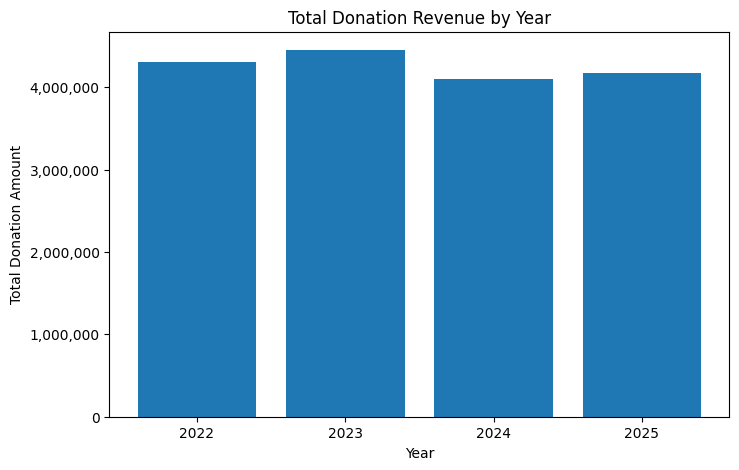

In [55]:
import matplotlib.ticker as mticker

plt.figure(figsize=(8,5))
plt.bar(yearly_donation_totals['donation_year'], yearly_donation_totals['donation_amount'])
plt.title('Total Donation Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Total Donation Amount')

# Set x-axis ticks to show actual integer years
plt.xticks(yearly_donation_totals['donation_year'])

# Format y-axis labels to include commas for better readability
formatter = mticker.FormatStrFormatter('%1.0f') # For integer values
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.show()

### Donation count by year

In [56]:
donation_count_by_year = df_donations.groupby('donation_year')['donation_id'].count().reset_index()

donation_count_by_year.rename(columns={'donation_id': 'donation_count'}, inplace=True)

donation_count_by_year

,donation_year,donation_count
0,2022,8824
1,2023,9227
2,2024,8584
3,2025,8365


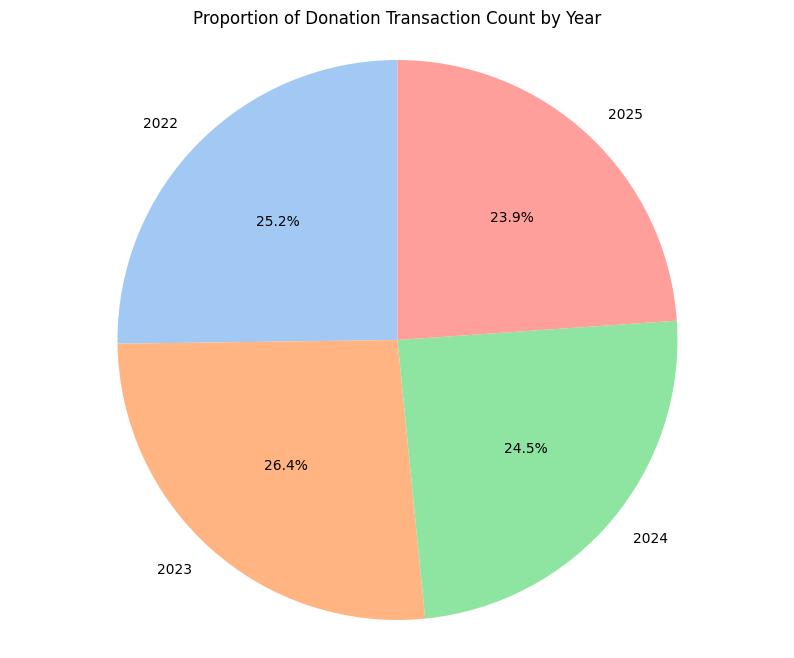

In [71]:
plt.figure(figsize=(10, 8))
plt.pie(donation_count_by_year['donation_count'], labels=donation_count_by_year['donation_year'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Proportion of Donation Transaction Count by Year')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### donor count by year

In [72]:
donor_count_by_year = df_donations.groupby('donation_year')['supporter_id'].nunique().reset_index()

donor_count_by_year.rename(columns={'supporter_id': 'unique_donor_count'}, inplace=True)

donor_count_by_year

,donation_year,unique_donor_count
0,2022,6593
1,2023,6891
2,2024,6506
3,2025,6516


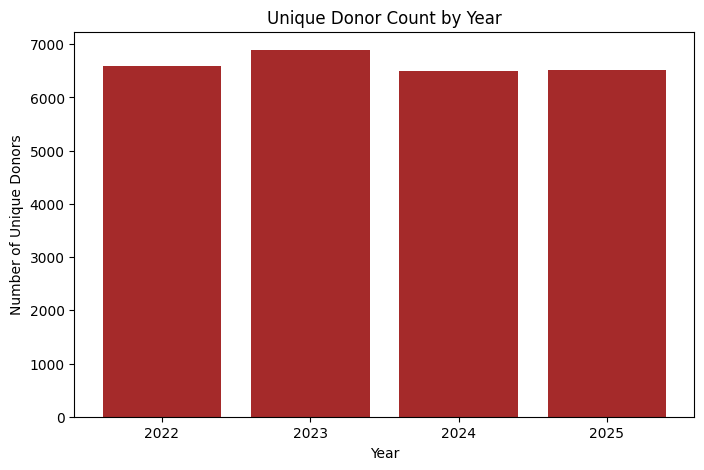

In [86]:
plt.figure(figsize=(8,5))
plt.bar(donor_count_by_year['donation_year'],
  donor_count_by_year['unique_donor_count'], color='brown')
plt.title('Unique Donor Count by Year')
plt.xticks(yearly_donation_totals['donation_year'])
plt.xlabel('Year')
plt.ylabel('Number of Unique Donors')
plt.show()

Combine yearly donation summary into one table


In [88]:
yearly_donation_summary = yearly_donation_totals.merge(
    donation_count_by_year,
    on='donation_year',
    how='left'
).merge(
    donor_count_by_year,
    on='donation_year',
    how='left'
)

yearly_donation_summary['average_donation'] = (
    yearly_donation_summary['donation_amount'] / yearly_donation_summary['donation_count']
).round(2)

yearly_donation_summary

,donation_year,donation_amount,donation_count,unique_donor_count,average_donation
0,2022,4306112,8824,6593,488.00
1,2023,4453146,9227,6891,482.62
2,2024,4102812,8584,6506,477.96
3,2025,4175947,8365,6516,499.22


Communication open/click rates by channel


In [91]:
communication_channel_summary = df_communications.groupby('contact_channel').agg(
    total_contacts=('contact_id', 'count'),
    delivered_count=('delivered', 'sum'),
    opened_count=('opened', 'sum'),
    clicked_count=('clicked', 'sum')
).reset_index()

communication_channel_summary['open_rate'] = (
    communication_channel_summary['opened_count'] / communication_channel_summary['delivered_count']
)

communication_channel_summary['click_rate'] = (
    communication_channel_summary['clicked_count'] / communication_channel_summary['delivered_count']
)

# Format open_rate and click_rate as percentages
communication_channel_summary['open_rate'] = communication_channel_summary['open_rate'].apply(lambda x: f"{x:.2%}")
communication_channel_summary['click_rate'] = communication_channel_summary['click_rate'].apply(lambda x: f"{x:.2%}")

communication_channel_summary

,contact_channel,total_contacts,delivered_count,opened_count,clicked_count,open_rate,click_rate
0,email,22488,22010,9756,2394,44.33%,10.88%
1,facebook_message,22523,22052,9702,2299,44.00%,10.43%
2,sms,17959,17625,7613,1632,43.19%,9.26%
3,whatsapp,27030,26498,11963,3022,45.15%,11.40%


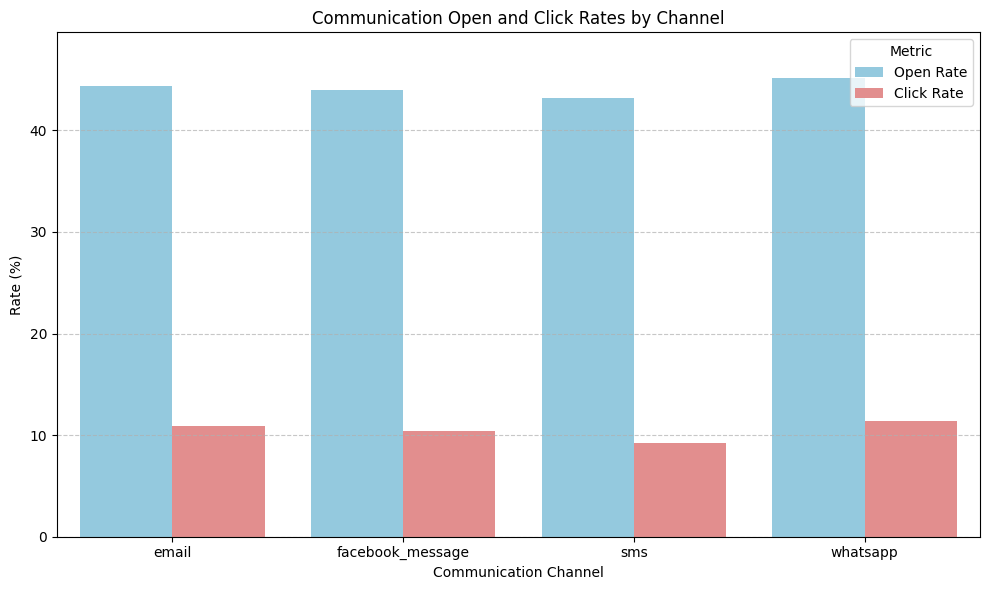

In [93]:


# Convert open_rate and click_rate back to numeric for plotting
communication_channel_summary['open_rate_numeric'] = communication_channel_summary['open_rate'].str.replace('%', '').astype(float)
communication_channel_summary['click_rate_numeric'] = communication_channel_summary['click_rate'].str.replace('%', '').astype(float)

# Melt the DataFrame for easier plotting with seaborn
df_melted_rates = communication_channel_summary.melt(
    id_vars=['contact_channel'],
    value_vars=['open_rate_numeric', 'click_rate_numeric'],
    var_name='Metric',
    value_name='Rate'
)

# Map the metric names for better legend labels
df_melted_rates['Metric'] = df_melted_rates['Metric'].map({
    'open_rate_numeric': 'Open Rate',
    'click_rate_numeric': 'Click Rate'
})

plt.figure(figsize=(10, 6))
sns.barplot(
    x='contact_channel',
    y='Rate',
    hue='Metric',
    data=df_melted_rates,
    palette={'Open Rate': 'skyblue', 'Click Rate': 'lightcoral'}
)

plt.title('Communication Open and Click Rates by Channel')
plt.xlabel('Communication Channel')
plt.ylabel('Rate (%)')
plt.ylim(0, df_melted_rates['Rate'].max() * 1.1) # Add some padding to the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

 Campaign performance by type


In [95]:
donations_campaigns = df_donations.merge(
    df_campaigns,
    on='campaign_id',
    how='left'
)

campaign_type_summary = donations_campaigns.groupby('campaign_type').agg(
    total_donation_amount=('donation_amount', 'sum'),
    donation_count=('donation_id', 'count'),
    unique_donors=('supporter_id', 'nunique'),
    average_donation=('donation_amount', 'mean')
).reset_index()

campaign_type_summary.sort_values(by='total_donation_amount', ascending=False)

,campaign_type,total_donation_amount,donation_count,unique_donors,average_donation
0,Digital Campaign,7807893,15987,10049,488.390129
1,Event,5405729,11215,7906,482.008827
2,Regular Giving Program,3824395,7798,6126,490.432803


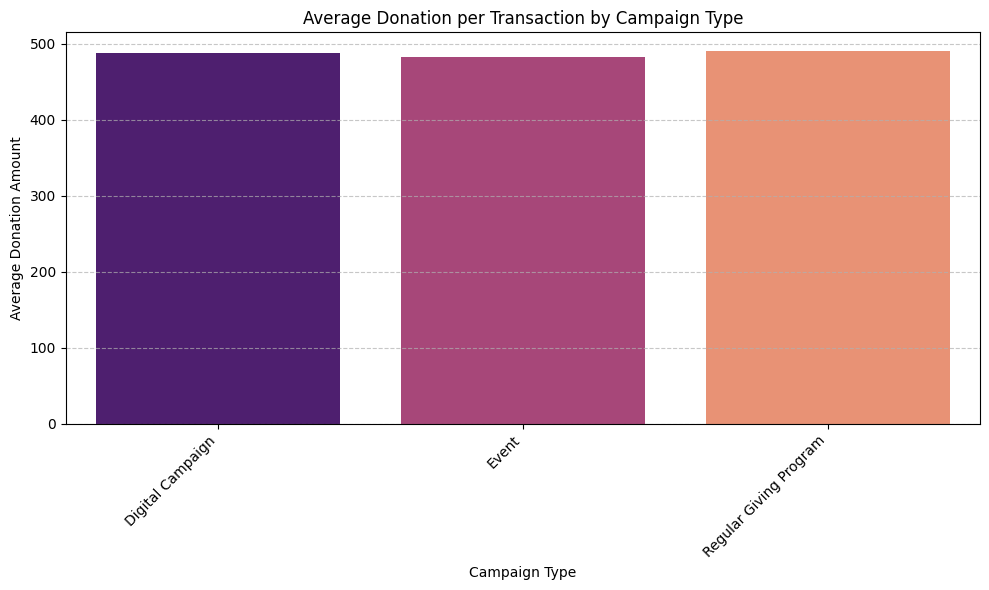

In [99]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='campaign_type',
    y='average_donation',
    data=campaign_type_summary,
    palette='magma',
    hue='campaign_type', legend=False
)

plt.title('Average Donation per Transaction by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Average Donation Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Campaign performance by theme

In [102]:
campaign_theme_summary = donations_campaigns.groupby('campaign_theme').agg(
    total_donation_amount=('donation_amount', 'sum'),
    donation_count=('donation_id', 'count'),
    unique_donors=('supporter_id', 'nunique'),
    average_donation=('donation_amount', 'mean')
).reset_index()

campaign_theme_summary.sort_values(by='total_donation_amount', ascending=False)

,campaign_theme,total_donation_amount,donation_count,unique_donors,average_donation
0,Child Education,4037417,8296,6349,486.670323
2,Healthcare Access,4016057,8348,6388,481.080139
4,Safe Water Initiative,3135422,6373,5216,491.985250
3,Nutrition Program,3047614,6362,5186,479.033952
1,Emergency Relief,2801507,5621,4730,498.400107


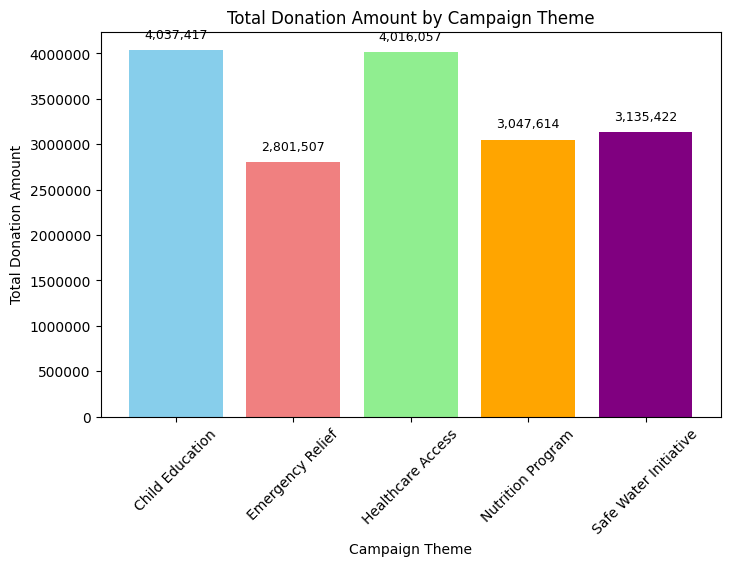

In [112]:
plt.figure(figsize=(8,5))
bars = plt.bar(campaign_theme_summary['campaign_theme'], campaign_theme_summary['total_donation_amount'], color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple']) # Added example colors

plt.title('Total Donation Amount by Campaign Theme')
plt.xlabel('Campaign Theme')
plt.ylabel('Total Donation Amount')
plt.xticks(rotation=45)

# Ensure y-axis shows full numbers (no scientific notation)
plt.ticklabel_format(style='plain', axis='y')

# Add text labels on top of each bar for exact values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100000, f'{yval:,.0f}', ha='center', va='bottom', fontsize=9)

plt.show()